# Numerical Integration Illustration
This notebook visualizes how the trapezoidal rule approximates the area under a curve.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.grid'] = True
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.labelsize'] = 18
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath, amsfonts, mathrsfs, amssymb}')

# plt.rc('font', family='Arial', size=12)
plt.rc('axes', titlesize=32, labelsize=32, grid=True)
plt.rc('lines', linewidth=2)
plt.rc('legend', fontsize=32, frameon=False)
plt.rc('xtick', labelsize=26, direction='in')
plt.rc('ytick', labelsize=26, direction='in')
plt.rcParams['lines.markersize'] = 14
plt.rc('figure', figsize=(6, 4), dpi=100)

In [3]:
# Positive function to integrate on [a, b]
def f(x):
    return 1.2 + 0.4 * np.sin(x) + 0.15 * x

# Interval and number of quadrature cells
a, b = 0, np.pi
n = 8

# Grid for smooth plotting
x_plot = np.linspace(a, b, 500)
y_plot = f(x_plot)

# Build a non-uniform partition so weights are NOT equal
t = np.linspace(0, 1, n + 1)
x_edges = a + (b - a) * t**1.6
w = np.diff(x_edges)                # unequal weights
x_q = 0.5 * (x_edges[:-1] + x_edges[1:])
y_q = f(x_q)

# General weighted quadrature sum: sum_i w_i f(x_i)
quad_area = np.sum(w * y_q)

# Reference integral value (high-resolution numeric approximation)
x_fine = np.linspace(a, b, 20000)
exact_area = np.trapezoid(f(x_fine), x_fine)

print(f'General weighted sum (n={n}): {quad_area:.6f}')
print(f'Reference integral value:      {exact_area:.6f}')
print(f'Absolute error:                {abs(exact_area - quad_area):.6f}')
print('Weights w_i:', np.array2string(w, precision=4))

General weighted sum (n=8): 5.317852
Reference integral value:      5.310132
Absolute error:                0.007721
Weights w_i: [0.1128 0.2291 0.3122 0.3823 0.4447 0.5016 0.5546 0.6043]


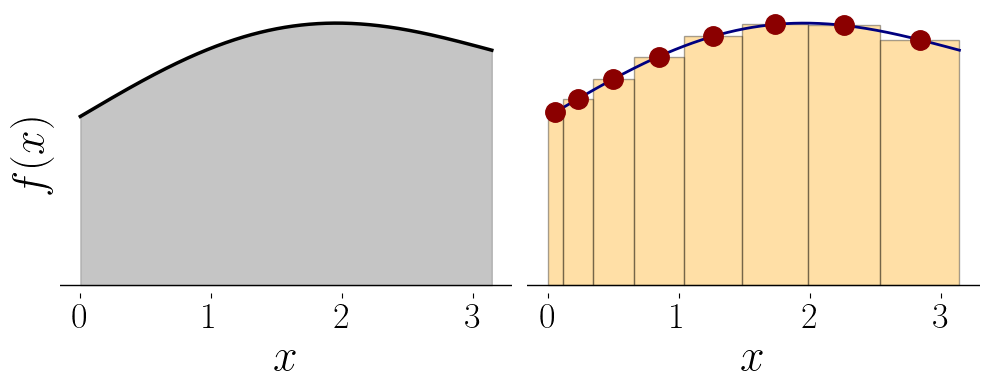

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax1, ax2 = axes

# Left: continuous integral illustration
ax1.plot(x_plot, y_plot, color='black', linewidth=2.5)
ax1.fill_between(x_plot, y_plot, 0, color='grey', alpha=0.45)
ax1.axhline(0, color='black', linewidth=1)
# ax1.set_title(r'Integral: $\int_a^b f(x)\,dx$', fontsize=26)
ax1.set_xlabel(r'$x$')
ax1.set_ylabel(r'$f(x)$')
ax1.grid(False)

# Right: unequal-weight quadrature illustration
for i in range(n):
    left = x_edges[i]
    width = w[i]
    height = y_q[i]
    ax2.add_patch(
        plt.Rectangle((left, 0), width, height, facecolor='orange', edgecolor='black', alpha=0.35)
    )

ax2.plot(x_plot, y_plot, color='navy', linewidth=2.0)
ax2.scatter(x_q, y_q, color='darkred', zorder=3)
ax2.axhline(0, color='black', linewidth=1)
# ax2.set_title(r'Cubature rule: $\sum_{i=0}^{n-1} w_i f(x_i)$', fontsize=26)
ax2.set_xlabel(r'$x$')
ax2.grid(False)

# Remove subplot frame lines and y-axis numeric values on both axes
for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('/home/zongchen/mini_mmd/figures/integral_illustration.pdf', dpi=300, bbox_inches='tight')
plt.show()
